## AUTO ENCODERS KERAS

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load the Fashion MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape the images to a 1D array
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Define the autoencoder architecture
input_img = Input(shape=(784,))  # 784 = 28x28
encoded = Dense(128, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
autoencoder.fit(x_train, x_train, epochs=10, batch_size=32, shuffle=True, validation_data=(x_test, x_test))

# Get the reconstructed images
decoded_imgs = autoencoder.predict(x_test)


Epoch 1/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3035 - val_loss: 0.2785
Epoch 2/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2719 - val_loss: 0.2707
Epoch 3/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2670 - val_loss: 0.2680
Epoch 4/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2649 - val_loss: 0.2662
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2636 - val_loss: 0.2656
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2630 - val_loss: 0.2650
Epoch 7/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2625 - val_loss: 0.2646
Epoch 8/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2622 - val_loss: 0.2647
Epoch 9/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2620 - val_loss: 0.2643
Epoch 10/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.261

In [ ]:
autoencoder.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense_12 (Dense)            (None, 128)               100480    
                                                                 
 dense_13 (Dense)            (None, 784)               101136    
                                                                 
Total params: 201616 (787.56 KB)
Trainable params: 201616 (787.56 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


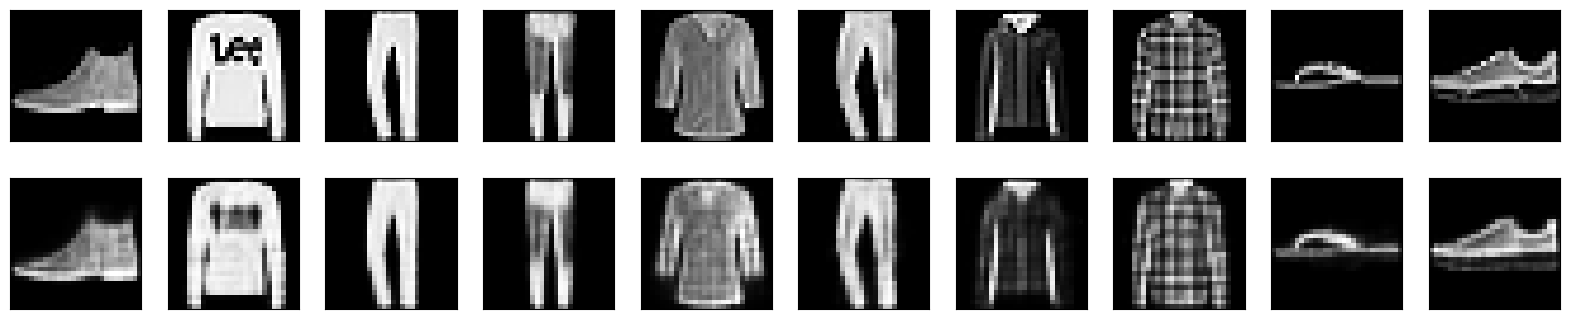

In [ ]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## AUTO ENCODERS RANDOM NUMPY DATA

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input , Dense
from tensorflow.keras.models import Model

X_train = np.random.rand(1000,200)

#compress into 5 features
encoding_dim = 20

input_data = Input(shape=(200,))


## high dim to low dimension
encoded = Dense(100,activation = 'relu')(input_data)
encoded = Dense(50,activation = 'relu')(encoded)
encoded = Dense(encoding_dim,activation = 'relu')(encoded)
# low dim to high dimension
decoded = Dense(50,activation = 'relu')(encoded)
decoded = Dense(100,activation = 'relu')(decoded)
decoded = Dense(200,activation = 'linear')(decoded)

autoencoder = Model(input_data  , decoded )



In [ ]:

autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200)]             0         
                                                                 
 dense (Dense)               (None, 100)               20100     
                                                                 
 dense_1 (Dense)             (None, 50)                5050      
                                                                 
 dense_2 (Dense)             (None, 20)                1020      
                                                                 
 dense_3 (Dense)             (None, 50)                1050      
                                                                 
 dense_4 (Dense)             (None, 100)               5100      
                                                                 
 dense_5 (Dense)             (None, 200)               20200 

 just remember IDENTITY FUNCTION = INPUT = OUTPUT

In [ ]:

autoencoder.compile(optimizer='adam' , loss = 'mse')

history = autoencoder.fit(X_train , X_train,
                          epochs = 20 ,
                          batch_size = 16,
                          shuffle = True)

Epoch 1/20
63/63 [==============================] - 2s 5ms/step - loss: 0.0770
Epoch 2/20
63/63 [==============================] - 0s 5ms/step - loss: 0.0766
Epoch 3/20
63/63 [==============================] - 0s 5ms/step - loss: 0.0763
Epoch 4/20
63/63 [==============================] - 0s 5ms/step - loss: 0.0761
Epoch 5/20
63/63 [==============================] - 0s 5ms/step - loss: 0.0759
Epoch 6/20
63/63 [==============================] - 0s 5ms/step - loss: 0.0756
Epoch 7/20
63/63 [==============================] - 0s 5ms/step - loss: 0.0755
Epoch 8/20
63/63 [==============================] - 0s 5ms/step - loss: 0.0753
Epoch 9/20
63/63 [==============================] - 0s 8ms/step - loss: 0.0751
Epoch 10/20
63/63 [==============================] - 0s 7ms/step - loss: 0.0749
Epoch 11/20
63/63 [==============================] - 0s 7ms/step - loss: 0.0748
Epoch 12/20
63/63 [==============================] - 0s 7ms/step - loss: 0.0746
Epoch 13/20
63/63 [==============================

In [ ]:
output = autoencoder.predict(X_train)

32/32 [==============================] - 0s 4ms/step


In [ ]:
output

array([[0.52670014, 0.45728898, 0.579846  , ..., 0.51052564, 0.43839893,
        0.5245596 ],
       [0.7069482 , 0.5136727 , 0.21854068, ..., 0.5586696 , 0.53457123,
        0.4460685 ],
       [0.50974685, 0.39487174, 0.57394487, ..., 0.40273827, 0.4261832 ,
        0.5861903 ],
       ...,
       [0.5250316 , 0.3883863 , 0.4036258 , ..., 0.48186055, 0.4755436 ,
        0.49119464],
       [0.49655238, 0.59493625, 0.61133605, ..., 0.54584116, 0.65911436,
        0.53317744],
       [0.37227196, 0.46431854, 0.50627124, ..., 0.4526595 , 0.5325687 ,
        0.44539198]], dtype=float32)

## MNIST NUMBERS AUTOENCODERS

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input , Dense
from tensorflow.keras.models import Model

Train shape : ((60000, 28, 28), (60000,))
Test shape : ((10000, 28, 28), (10000,))


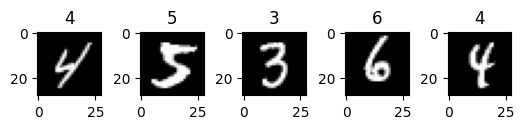

In [ ]:
(trainX , trainY) , (testX , testY) = mnist.load_data()
print('Train shape :' , (trainX.shape , trainY.shape))
print('Test shape :' , (testX.shape , testY.shape))

for j in range(5):
  i = np.random.randint(0,10000)
  plt.subplot(550+1+j)
  plt.imshow(trainX[i] , cmap = 'gray')
  plt.title(trainY[i])
plt.show()


In [ ]:
# no need to normalize

# directly flatten
train_data = np.reshape(trainX , (60000 , 28*28))
test_data = np.reshape(testX , (10000 , 28*28))

print(train_data.shape , test_data.shape)


(60000, 784) (10000, 784)


In [ ]:
input_data = Input(shape=(784,))
encoder = Dense(100,activation = 'relu')(input_data)
encoder = Dense(50,activation = 'relu')(encoder)
encoder = Dense(25,activation = 'relu')(encoder)
encoded = Dense(2)(encoder)


In [ ]:
decoder = Dense(25,activation = 'relu')(encoded)
decoder = Dense(50,activation = 'relu')(decoder)
decoder = Dense(100,activation = 'relu')(decoder)
decoded = Dense(784)(decoder)

In [ ]:
autoencoder = Model(inputs = input_data , outputs = decoded)
autoencoder.compile(loss = 'mse' , optimizer='adam')
autoencoder.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense_4 (Dense)             (None, 100)               78500     
                                                                 
 dense_5 (Dense)             (None, 50)                5050      
                                                                 
 dense_6 (Dense)             (None, 25)                1275      
                                                                 
 dense_7 (Dense)             (None, 2)                 52        
                                                                 
 dense_8 (Dense)             (None, 25)                75        
                                                                 
 dense_9 (Dense)             (None, 50)                1300

You  can even print individual layers in summary

In [ ]:
history = autoencoder.fit(train_data , train_data , epochs = 40 , batch_size = 256 , validation_data = (test_data , test_data))

Epoch 1/40
235/235 [==============================] - 1s 5ms/step - loss: 2621.4729 - val_loss: 2637.0439
Epoch 2/40
235/235 [==============================] - 1s 5ms/step - loss: 2625.7820 - val_loss: 2636.3601
Epoch 3/40
235/235 [==============================] - 1s 5ms/step - loss: 2622.0774 - val_loss: 2617.8435
Epoch 4/40
235/235 [==============================] - 1s 5ms/step - loss: 2609.1311 - val_loss: 2658.3914
Epoch 5/40
235/235 [==============================] - 1s 5ms/step - loss: 2627.5525 - val_loss: 2666.2307
Epoch 6/40
235/235 [==============================] - 1s 6ms/step - loss: 2610.7759 - val_loss: 2650.3831
Epoch 7/40
235/235 [==============================] - 2s 7ms/step - loss: 2616.9358 - val_loss: 2606.7498
Epoch 8/40
235/235 [==============================] - 1s 5ms/step - loss: 2609.3220 - val_loss: 2659.9482
Epoch 9/40
235/235 [==============================] - 1s 5ms/step - loss: 2670.1096 - val_loss: 2638.4116
Epoch 10/40
235/235 [=========================

313/313 [==============================] - 1s 2ms/step


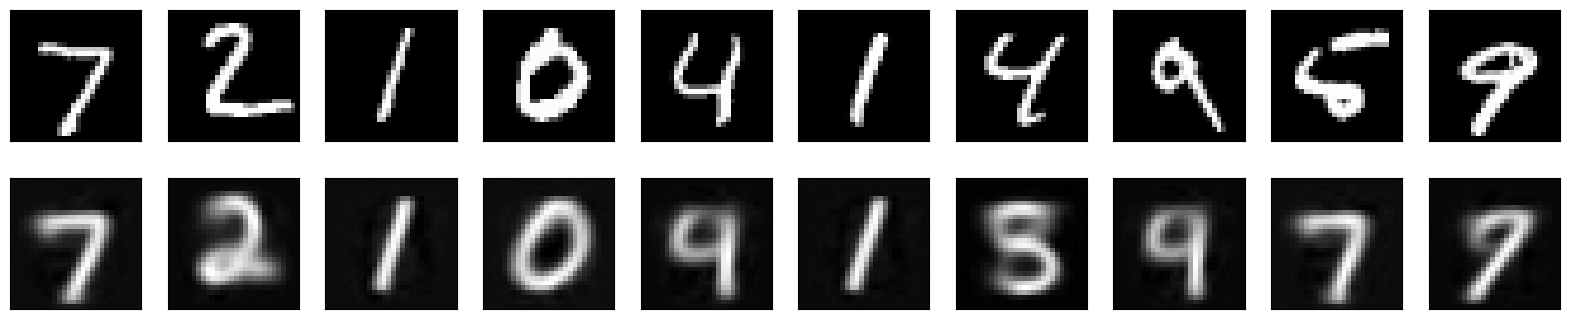

In [ ]:
import matplotlib.pyplot as plt
encoded_imgs = autoencoder.predict(test_data)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_data[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [ ]:
autoencoder.save('autencoder.h5')

USING CNN


AUTO ENCODER CNN

Train shape : ((60000, 28, 28), (60000,))
Test shape : ((10000, 28, 28), (10000,))
(60000, 784) (10000, 784)
313/313 [==============================] - 1s 2ms/step


<Figure size 2000x600 with 0 Axes>

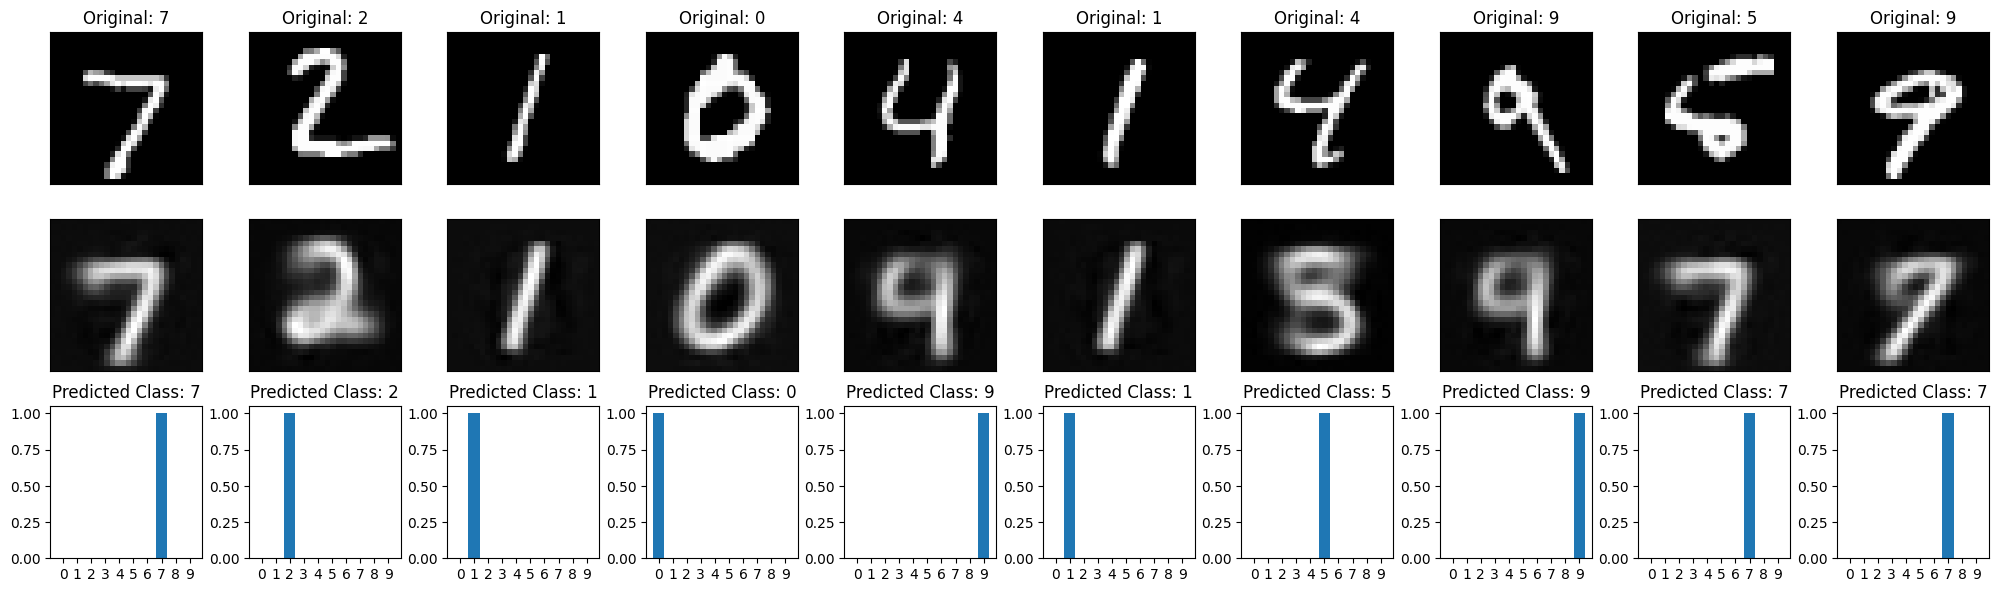

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input , Dense
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

# no need to normalize
(trainX , trainY) , (testX , testY) = mnist.load_data()
print('Train shape :' , (trainX.shape , trainY.shape))
print('Test shape :' , (testX.shape , testY.shape))


# directly flatten
train_data = np.reshape(trainX , (60000 , 28*28))
test_data = np.reshape(testX , (10000 , 28*28))

print(train_data.shape , test_data.shape)

# Load the autoencoder model
autoencoder = load_model('/content/autencoder.h5')

# Load the CNN model for digit classification
cnn_model = load_model('final_model.h5')

# Generate images using the autoencoder
encoded_imgs = autoencoder.predict(test_data)

# Reshape encoded images to match the input shape expected by the CNN model
encoded_imgs_reshaped = encoded_imgs.reshape(-1, 28, 28, 1)

# Predict on the reshaped generated images using the CNN model
predicted_classes = cnn_model.predict(encoded_imgs_reshaped)

# Plot the original and generated images along with their predicted classes
n = 10
# Plot the original and generated images along with their predicted classes
plt.figure(figsize=(20, 6))

for i in range(n):
    # Display original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(test_data[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title(f'Original: {testY[i]}')  # Add original class as title

    # Display generated image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display predicted class
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.bar(range(10), predicted_classes[i])
    plt.xticks(range(10))
    ax.set_title(f'Predicted Class: {np.argmax(predicted_classes[i])}')  # Add predicted class as title

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


1/1 [==============================] - 0s 106ms/step
Input Digit Class: 8
Generated Image:


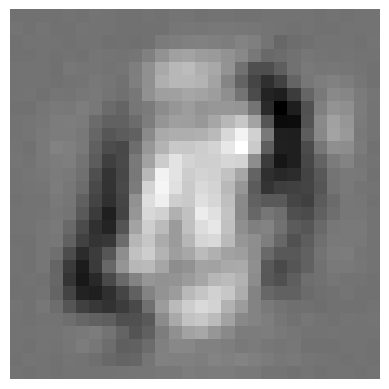

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt

# Load the CNN model for digit classification
cnn_model = load_model('/content/cnn_mnist.h5')

# Load the autoencoder model for digit generation
autoencoder_model = load_model('/content/autencoder.h5')

# Define a function to combine both models
def generate_digit_image(input_digit):
    # Reshape the input digit to match the shape expected by the autoencoder model
    input_digit = np.reshape(input_digit, (1, 784))

    # Classify the input digit using the CNN model
    digit_class = np.argmax(cnn_model.predict(np.reshape(input_digit, (1, 28, 28, 1))))

    # Generate an image of the input digit using the autoencoder model
    generated_image = autoencoder_model.predict(input_digit)

    return digit_class, generated_image

# Test the combined model by providing a digit as input
input_digit = np.random.rand(28, 28, 1)  # You can replace this with any input digit
digit_class, generated_image = generate_digit_image(input_digit)

print("Input Digit Class:", digit_class)
print("Generated Image:")
plt.imshow(generated_image.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()


## WEIGHT TYING CONCEPT FASHION DATASET

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import keras
import numpy as np


(X_train , _) ,(X_test ,  _) = keras.datasets.fashion_mnist.load_data()

In [ ]:
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

#flatten

X_train =  X_train.reshape((len(X_train) , np.prod(X_train.shape[1:])))

X_test =  X_test.reshape((len(X_test) , np.prod(X_test.shape[1:])))


In [ ]:
class Autoencoder(tf.keras.Model):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        self.encoding_dim = encoding_dim
        self.encoder = tf.keras.layers.Dense(encoding_dim, activation='relu')
        self.decoder = tf.keras.layers.Dense(input_dim, activation='sigmoid')
        self.decoder.set_weights(self._initialize_decoder_weights())

    def _initialize_decoder_weights(self):
        encoder_weights = self.encoder.get_weights()
        decoder_weights = [tf.transpose(w) for w in encoder_weights]
        return decoder_weights

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded  # Return the output of the decoder

input_dim = 784
encoding_dim = 64

autoencoder = Autoencoder(input_dim, encoding_dim)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder.fit(X_train, X_train, epochs=10, batch_size=256, shuffle=True, validation_data=(X_test, X_test))


Epoch 1/10
235/235 [==============================] - 2s 5ms/step - loss: 0.3912 - val_loss: 0.3289
Epoch 2/10
235/235 [==============================] - 1s 5ms/step - loss: 0.3145 - val_loss: 0.3072
Epoch 3/10
235/235 [==============================] - 1s 6ms/step - loss: 0.2993 - val_loss: 0.2968
Epoch 4/10
235/235 [==============================] - 1s 4ms/step - loss: 0.2904 - val_loss: 0.2893
Epoch 5/10
235/235 [==============================] - 1s 4ms/step - loss: 0.2850 - val_loss: 0.2854
Epoch 6/10
235/235 [==============================] - 1s 4ms/step - loss: 0.2815 - val_loss: 0.2825
Epoch 7/10
235/235 [==============================] - 1s 4ms/step - loss: 0.2793 - val_loss: 0.2808
Epoch 8/10
235/235 [==============================] - 1s 4ms/step - loss: 0.2778 - val_loss: 0.2795
Epoch 9/10
235/235 [==============================] - 1s 4ms/step - loss: 0.2766 - val_loss: 0.2783
Epoch 10/10
235/235 [==============================] - 1s 4ms/step - loss: 0.2757 - val_loss: 0.2776

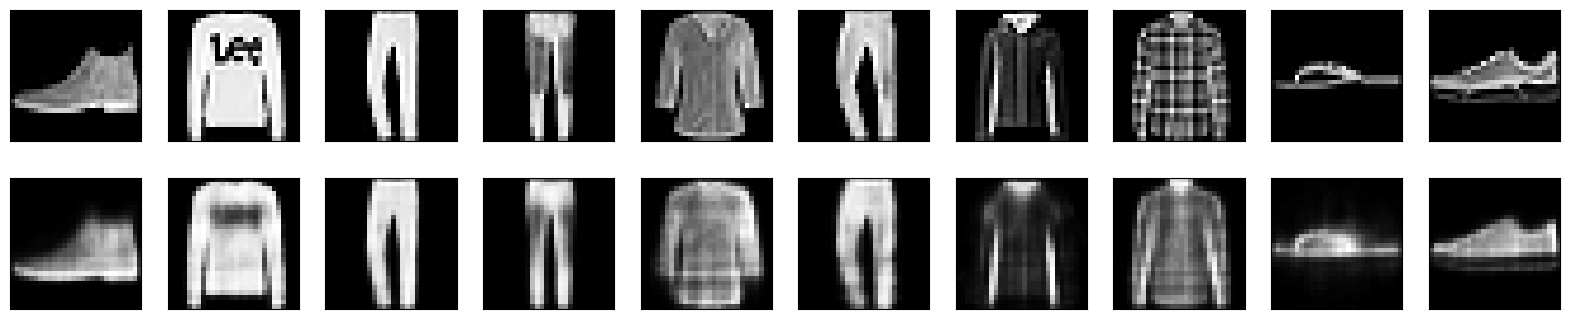

In [ ]:
import matplotlib.pyplot as plt

encoded_imgs = autoencoder.encoder(X_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## WEIGHT TYING CONCEPT MNIST DATASET

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import keras
import numpy as np

(X_train , _) ,(X_test ,  _) = mnist.load_data()

11490434/11490434 [==============================] - 2s 0us/step


In [ ]:
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

#flatten

X_train =  X_train.reshape((len(X_train) , np.prod(X_train.shape[1:])))

X_test =  X_test.reshape((len(X_test) , np.prod(X_test.shape[1:])))


In [ ]:
class Autoencoder(tf.keras.Model):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        self.encoding_dim = encoding_dim
        self.encoder = tf.keras.layers.Dense(encoding_dim, activation='relu')
        self.decoder = tf.keras.layers.Dense(input_dim, activation='sigmoid')
        self.decoder.set_weights(self._initialize_decoder_weights())

    def _initialize_decoder_weights(self):
        encoder_weights = self.encoder.get_weights()
        decoder_weights = [tf.transpose(w) for w in encoder_weights]
        return decoder_weights

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded  # Return the output of the decoder

input_dim = 784
encoding_dim = 64

autoencoder = Autoencoder(input_dim, encoding_dim)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder.fit(X_train, X_train, epochs=10, batch_size=256, shuffle=True, validation_data=(X_test, X_test))


Epoch 1/10
235/235 [==============================] - 2s 4ms/step - loss: 0.2428 - val_loss: 0.1606
Epoch 2/10
235/235 [==============================] - 1s 4ms/step - loss: 0.1428 - val_loss: 0.1267
Epoch 3/10
235/235 [==============================] - 1s 4ms/step - loss: 0.1181 - val_loss: 0.1084
Epoch 4/10
235/235 [==============================] - 1s 5ms/step - loss: 0.1036 - val_loss: 0.0971
Epoch 5/10
235/235 [==============================] - 1s 5ms/step - loss: 0.0943 - val_loss: 0.0897
Epoch 6/10
235/235 [==============================] - 1s 4ms/step - loss: 0.0880 - val_loss: 0.0847
Epoch 7/10
235/235 [==============================] - 1s 6ms/step - loss: 0.0838 - val_loss: 0.0812
Epoch 8/10
235/235 [==============================] - 1s 4ms/step - loss: 0.0809 - val_loss: 0.0789
Epoch 9/10
235/235 [==============================] - 1s 4ms/step - loss: 0.0789 - val_loss: 0.0773
Epoch 10/10
235/235 [==============================] - 1s 4ms/step - loss: 0.0775 - val_loss: 0.0762

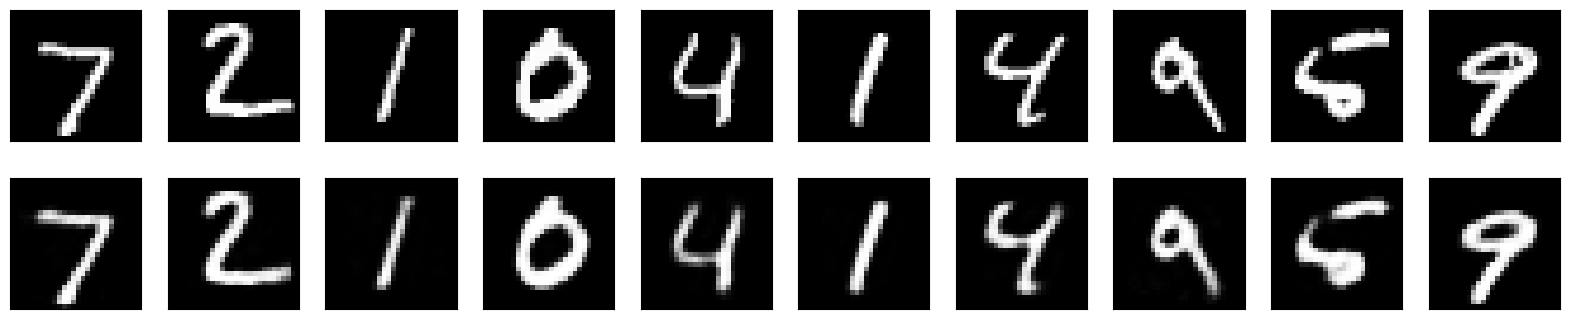

In [ ]:
import matplotlib.pyplot as plt

encoded_imgs = autoencoder.encoder(X_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## VAE FULL STORY

### Reparamaterization trick back story

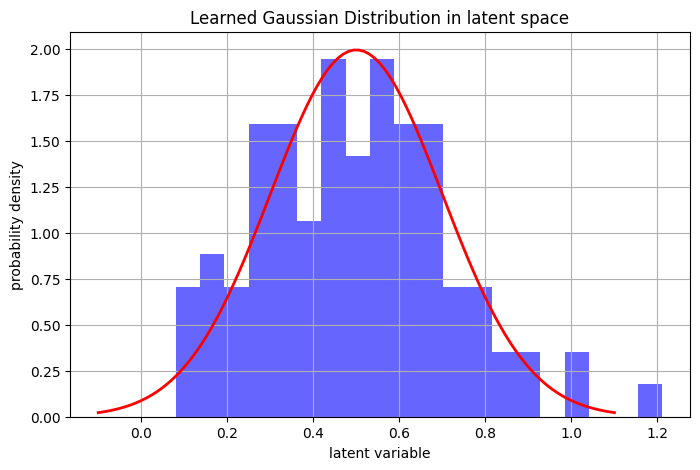

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu = 0.5
sigma = 0.2
num_samples = 100

#sampling from gaussin distribution
latent_smaples = np.random.normal(mu , sigma , num_samples)
plt.figure(figsize=(8,5))
plt.hist(latent_smaples , bins= 20 , density = True , alpha = 0.6 , color = 'b')
x = np.linspace(mu-3*sigma , mu + 3*sigma , 100)
#gaussian distribution
plt.plot(x , 1/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-mu)**2/(2*sigma**2)) , linewidth = 2 , color = 'r')

plt.xlabel('latent variable')
plt.ylabel('probability density')
plt.title('Learned Gaussian Distribution in latent space')
plt.grid(True)
plt.show()

### Interpolation

In [ ]:
import numpy as np

# selecting 2 latent represenation

z1 = np.array([0.2]) # example latent representation 1
z2 = np.array([0.8]) # example latent representation 2

# genreating intermediate points (linear interpolation)
num_interpolations = 5
interpolated_points = []

for i in range(num_interpolations + 2):  # +2 to include z1 and z2
  lamba_i = i /(num_interpolations + 1)
  # lambda is a scaled parameter
  # interpolation = ( 1-t) * z1 + t * z2
  # t should be between 0 and 1
  interpolated_point = (1 - lamba_i) * z1 + lamba_i * z2
  interpolated_points.append(interpolated_point)

In [ ]:
interpolated_points

[array([0.2]),
 array([0.3]),
 array([0.4]),
 array([0.5]),
 array([0.6]),
 array([0.7]),
 array([0.8])]

### reparamaterization trick , To differetiate

In [ ]:
import numpy as np

# Distribution Trick : sampling from a gaussian distribution
def sample_normal_gaussian(mu , sigma , num_samples):
  return np.random.normal(mu , sigma , num_samples)

# Reparamaterization TRick
def reparamaterize(mu , sigma , num_samples):
  mu = np.array(mu)
  epsilon = np.random.normal(0 , 1 ,(num_samples , ) + mu.shape)  # sample noise from gaussian distribtion
  return mu + sigma * epsilon

mu = 0.5
sigma = 0.2
num_samples = 10


# Distribution Trick : sampling from a gaussian distribution
latent_samples = sample_normal_gaussian(mu , sigma , num_samples)
print("Gaussian Samples:", latent_samples)

# Reparamaterization Trick
reparamaterized_samples = reparamaterize(mu , sigma , num_samples)
print("Reparamaterized Samples:", reparamaterized_samples)

Gaussian Samples: [0.21134554 0.72191321 0.49891157 0.63186996 0.97331813 0.74107288
 0.51943842 0.33386401 0.55984995 0.62997264]
Reparamaterized Samples: [0.84546291 0.17122394 0.26193707 0.80531044 0.26098601 0.8365303
 0.25630312 0.72111901 0.66500172 0.45771824]


### KL DIVERGENCE = cross etropy - entropy

we have seen reconstruction loss before so lets keep that aside for now and see whats kl divergence


KL divergence = p(x)log(p(x) / q(x))

In [ ]:
import numpy as np

# Distribution Trick : sampling from a gaussian distribution
def sample_normal_gaussian(mu , sigma , num_samples):
  return np.random.normal(mu , sigma , num_samples)

# Reparamaterization TRick
def reparamaterize(mu , sigma , num_samples):
  mu = np.array(mu)
  epsilon = np.random.normal(0 , 1 ,(num_samples , ) + mu.shape)  # sample noise from gaussian distribtion
  return mu + sigma * epsilon

def kl_divergence(mu_q , sigmaq ,mu_p , sigma_p):
  kl = np.log(sigma_p/sigma_q) + (sigma_q**2 + (mu_q - mu_p)**2)/(2*sigma_p**2) - 0.5
  return np.sum(kl)

# p and q are 2 gaussian distributions
mu_q = 0.5
sigma_q = 0.2
mu_p = 0.6
sigma_p = 0.3
num_samples = 1000

# Distribution Trick : sampling from a gaussian distribution
latent_samples = sample_normal_gaussian(mu_q , sigma_q , num_samples)
print("Gaussian Samples:", latent_samples)

# Reparamaterization Trick
reparamaterized_samples = reparamaterize(mu_q , sigma_q , num_samples)
print("Reparamaterized Samples:", reparamaterized_samples)

kl_value = kl_divergence(mu_q , sigma_q , mu_p , sigma_p)
print("KL Divergence:", kl_value)

# less divergence is good


Gaussian Samples: [ 0.63451867  0.16821936  0.39362396  0.52674389  0.7170468   0.27943544
  0.4786673   0.53359425  0.76715234  0.59679554  0.0954429   0.5650759
  0.31615198  0.47137731  0.46922613  0.68708641  0.80490329  0.41062481
  0.10142474  0.29823951  0.09802297  0.68164678  0.50315524  0.60392256
  0.37807128  0.31165136  0.59544838  0.36067573  0.57275938  0.64165405
  1.01364814  0.35572878  0.68632374  0.82032146  0.19167721  0.52638375
  0.49318721  0.69288619  0.55216012  0.63197287  0.57300003  0.67803825
  0.51759435  0.30247523  0.66835962  0.52069189  0.75502689  0.30848961
  0.30407905  0.6240364   0.40132538  0.87459837  0.61091499  0.51673651
  0.33658249  0.70523227  0.5871147   0.29140991  0.66753996  0.38516693
  0.45198436  0.67428157  0.89200216  0.50007018  0.62847269  0.30171515
  0.4986102   0.32926654  0.65997411  0.41027173  0.64212862  0.56133709
  0.45160951  0.19494945  0.28656543  0.43425041  0.52888977  0.17519348
  0.50556133  0.47104126  0.624755

Plotting KL divergence

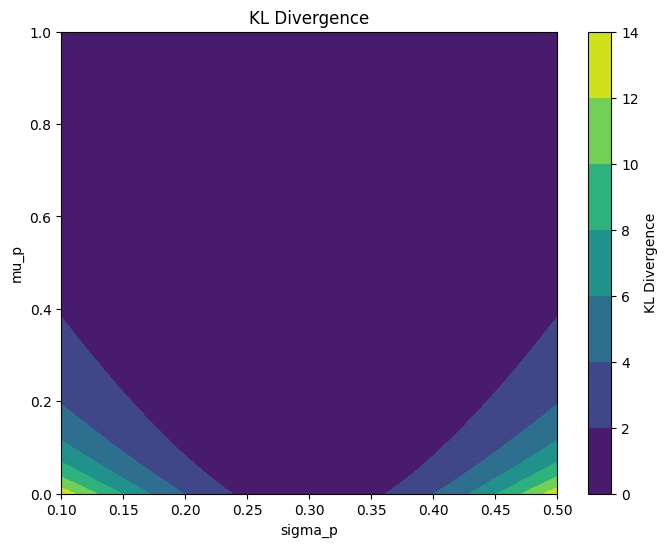

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def kl_divergence(mu_q, sigma_q, mu_p, sigma_p):
    kl = np.log(sigma_p/sigma_q) + (sigma_q**2 + (mu_q - mu_p)**2)/(2*sigma_p**2) - 0.5
    return np.sum(kl)

# range of values for mu_p and sigma_p
mu_p_range = np.linspace(0, 1, 100)
sigma_p_range = np.linspace(0.1, 0.5, 100)

# fixed mu_q and sigma_q values
mu_q = 0.5
sigma_q = 0.2

# compute kl divergence for each combination of mu_p and sigma_p
kl_values = np.zeros((len(mu_p_range), len(sigma_p_range)))
for i, mu_p in enumerate(mu_p_range):
    for j, sigma_p in enumerate(sigma_p_range):
        kl_values[i, j] = kl_divergence(mu_q, sigma_q, mu_p, sigma_p)

# plot the KL divergence as a heatmap
plt.figure(figsize=(8, 6))
plt.contourf(sigma_p_range, mu_p_range, kl_values.T, cmap='viridis')
plt.xlabel('sigma_p')
plt.ylabel('mu_p')
plt.title('KL Divergence')
plt.colorbar(label='KL Divergence')
plt.show()


### VAE ONE SHOT

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

In [ ]:

# this sampling layer is the bottleneck layer of VAE ,
# it used the output from two dense layers z_mean and z_log_var as input ,
# convert them into normal distribution and pass them to decoder layer

# when u give input vae will do this

class Sampling(layers.Layer):
  """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
  def call(self, inputs):
    mean , log_var = inputs
    batch = tf.shape(mean)[0]
    dim = tf.shape(mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return mean + tf.exp(0.5 * log_var) * epsilon


Encoder in making


In [ ]:
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28 , 1))
x= layers.Conv2D(64 , 3 , strides = 2 , activation = 'relu' ,padding = 'same')(encoder_inputs)
x = layers.Conv2D(128 , 3 , strides = 2 , activation = 'relu' ,padding = 'same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16 , activation = 'relu')(x)
mean = layers.Dense(latent_dim , name = "mean")(x)
log_var = layers.Dense(latent_dim , name = "log_var")(x)
z = Sampling()([mean , log_var])
encoder = keras.Model(encoder_inputs , [mean , log_var , z] , name = "encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 conv2d_4 (Conv2D)           (None, 14, 14, 64)           640       ['input_7[0][0]']             
                                                                                                  
 conv2d_5 (Conv2D)           (None, 7, 7, 128)            73856     ['conv2d_4[0][0]']            
                                                                                                  
 flatten_2 (Flatten)         (None, 6272)                 0         ['conv2d_5[0][0]']            
                                                                                            

Strides and feature maps have a relation through resolution

In [ ]:

latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7*7*64 , activation = 'relu')(latent_inputs)
x = layers.Reshape(( 7 , 7  , 64 ))(x)
x = layers.Conv2DTranspose(128 , 3 ,activation = 'relu', strides = 2 , padding = 'same')(x)
x = layers.Conv2DTranspose(64 , 3 , strides = 2 , padding = 'same' , activation = 'relu')(x)
decoder_ouputs = layers.Conv2DTranspose(1 , 3 , activation = 'sigmoid' , padding = 'same')(x)
decoder = keras.Model(latent_inputs , decoder_ouputs , name = "decoder")
decoder.summary()



Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_8 (Dense)             (None, 3136)              9408      
                                                                 
 reshape_3 (Reshape)         (None, 7, 7, 64)          0         
                                                                 
 conv2d_transpose_2 (Conv2D  (None, 14, 14, 128)       73856     
 Transpose)                                                      
                                                                 
 conv2d_transpose_3 (Conv2D  (None, 28, 28, 64)        73792     
 Transpose)                                                      
                                                                 
 conv2d_transpose_4 (Conv2D  (None, 28, 28, 1)         577 

In [ ]:

class VAE(keras.Model):
  def __init__(self , encoder , decoder , **kwargs):
    super().__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
    self.reconstruction_loss_tracker = keras.metrics.Mean(
        name="reconstruction_loss"
    )
    self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

  @property
  def metrics(self):
    return [
        self.total_loss_tracker,
        self.reconstruction_loss_tracker,
        self.kl_loss_tracker,
    ]

  def train_step(self , data):
    with tf.GradientTape() as tape:
      mean , log_var , z = self.encoder(data)
      reconstruction = self.decoder(z)
      reconstruction_loss = tf.reduce_mean(
          tf.reduce_sum(
              keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2),))
      kl_loss = -0.5 * ( 1 + log_var - tf.square(mean) - tf.exp(log_var))
      kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
      total_loss = reconstruction_loss + kl_loss

    grads = tape.gradient(total_loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
    self.total_loss_tracker.update_state(total_loss)
    self.reconstruction_loss_tracker.update_state(reconstruction_loss)
    self.kl_loss_tracker.update_state(kl_loss)
    return {
        "loss": self.total_loss_tracker.result(),
        "reconstruction_loss": self.reconstruction_loss_tracker.result(),
        "kl_loss": self.kl_loss_tracker.result(),
    }

In [ ]:
# lets train this on mnist data

(X_train , _) , (X_test , _) = keras.datasets.mnist.load_data()
mnist = np.concatenate([X_train , X_test] , axis = 0)
mnist = np.expand_dims(mnist , -1 ).astype("float32")/255

vae = VAE(encoder , decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(mnist , epochs = 5 , batch_size = 128)

Epoch 1/5
547/547 [==============================] - 15s 15ms/step - loss: 244.0164 - reconstruction_loss: 204.2671 - kl_loss: 3.1662
Epoch 2/5
547/547 [==============================] - 8s 14ms/step - loss: 183.3740 - reconstruction_loss: 171.5783 - kl_loss: 5.2427
Epoch 3/5
547/547 [==============================] - 8s 14ms/step - loss: 165.7533 - reconstruction_loss: 157.9505 - kl_loss: 6.0574
Epoch 4/5
547/547 [==============================] - 8s 14ms/step - loss: 160.5087 - reconstruction_loss: 153.2524 - kl_loss: 6.2802
Epoch 5/5
547/547 [==============================] - 8s 14ms/step - loss: 157.1681 - reconstruction_loss: 150.8658 - kl_loss: 6.3548


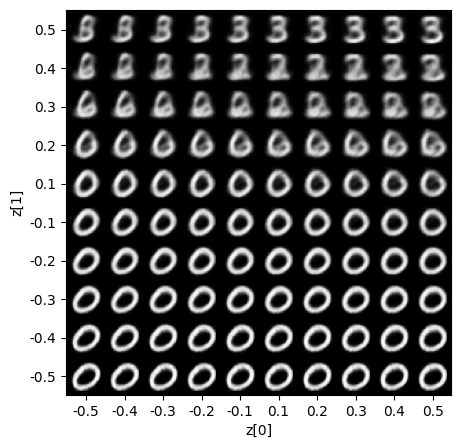

In [ ]:
from itertools import starmap
import matplotlib.pyplot as plt

def plot_latent_space(vae , n = 10 , figsize=5):
  # display a n * n 2D manifold of digits
  img_size = 28
  scale= 0.5
  figure = np.zeros((img_size * n, img_size * n))

  grid_x = np.linspace(-scale, scale, n)
  grid_y = np.linspace(-scale, scale, n)[::-1]

  for i , yi in enumerate(grid_y):
    for j , xi in enumerate(grid_x):
      sample = np.array([[xi , yi]])
      x_decoded = vae.decoder.predict(sample , verbose  = 0)
      images = x_decoded.reshape(img_size , img_size)
      figure[i * img_size : (i + 1) * img_size,
             j * img_size : (j + 1) * img_size] = images

  plt.figure(figsize=(figsize, figsize))
  start_range = img_size // 2
  end_range = n * img_size + start_range
  pixel_range = np.arange(start_range, end_range, img_size)

  sample_range_x = np.round(grid_x, 1)
  sample_range_y = np.round(grid_y, 1)
  plt.xticks(pixel_range, sample_range_x)
  plt.yticks(pixel_range, sample_range_y)
  plt.xlabel("z[0]")
  plt.ylabel("z[1]")
  plt.imshow(figure, cmap='Greys_r')
  plt.show()

plot_latent_space(vae)


## GAN NETWROK

Using numpy data

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers,  models



In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
num_points = 10
latent_dim = 2


In [ ]:
def build_discriminator():   # fool this and maximize loss
  model = models.Sequential([
      layers.Dense(64 , activation = 'relu' , input_shape = (2 ,) ),
      layers.Dense(32 , activation = 'relu' ),
      layers.Dense(1 , activation = 'sigmoid')  # real or fake
  ])
  return model

In [ ]:
def build_generator():  #minimize loss
  model = models.Sequential([
      layers.Dense(32 , activation = 'relu' , input_shape = (latent_dim ,) ),
      layers.Dense(64 , activation = 'relu' ),
      layers.Dense(2 , activation = 'tanh')
  ])
  return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

In [ ]:

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

# from_logits = True means the values ​​of the loss obtained by the model are not normalized
# and is basically used when we don't have any softmax function in our model.

In [ ]:
EPOCHS = 300
BATCH_SIZE = 32

In [ ]:

for epoch in range(EPOCHS):
    noise = tf.random.normal(shape=(BATCH_SIZE, latent_dim))
    generated_data = generator(noise, training=True)
    real_data = tf.random.uniform(shape=(BATCH_SIZE, 2), minval=-1, maxval=1)

    with tf.GradientTape() as disc_tape:
        disc_real_output = discriminator(real_data, training=True)
        disc_fake_output = discriminator(generated_data, training=True)
        disc_loss = cross_entropy(tf.ones_like(disc_real_output), disc_real_output) + cross_entropy(tf.zeros_like(disc_fake_output), disc_fake_output)

    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    noise = tf.random.normal(shape=(BATCH_SIZE, latent_dim))
    with tf.GradientTape() as gen_tape:
        generated_data = generator(noise, training=True)
        disc_fake_output = discriminator(generated_data, training=True)
        gen_loss = cross_entropy(tf.ones_like(disc_fake_output), disc_fake_output)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Discriminator Loss: {disc_loss}, Generator Loss: {gen_loss}")


Epoch 100/300, Discriminator Loss: 1.3338618278503418, Generator Loss: 0.7508538961410522
Epoch 200/300, Discriminator Loss: 1.3609750270843506, Generator Loss: 0.6468122601509094
Epoch 300/300, Discriminator Loss: 1.5197312831878662, Generator Loss: 0.7902007102966309


<function matplotlib.pyplot.show(close=None, block=None)>

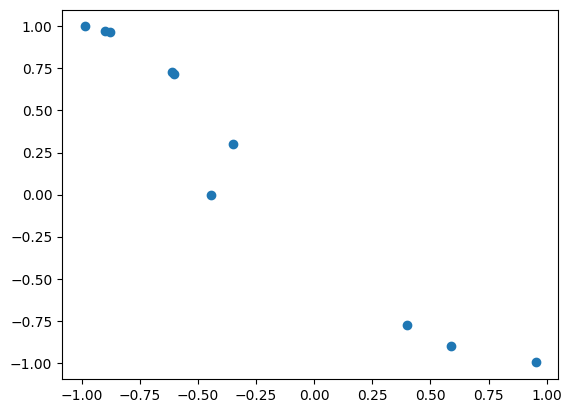

In [ ]:
noise = tf.random.normal([num_points , latent_dim])
generated_data = generator(noise, training=False).numpy()
plt.scatter(generated_data[:, 0], generated_data[:, 1])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

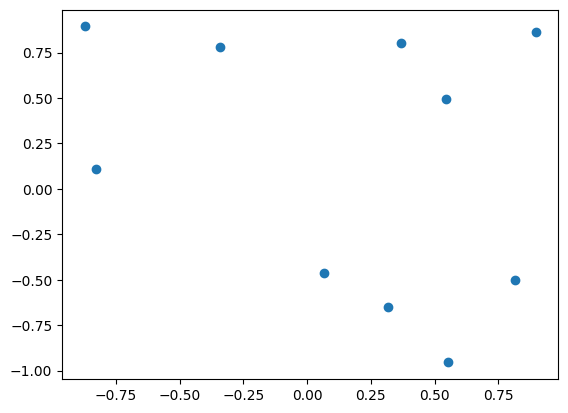

In [ ]:
# plot real data

real_data = tf.random.uniform(shape=(num_points, 2), minval=-1, maxval=1)
plt.scatter(real_data[:, 0], real_data[:, 1])
plt.show